<a href="https://colab.research.google.com/github/badaraaliouguindo/sentiment-analysis-multilingual/blob/main/notebooks/01_EDA_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installation des librairies

In [12]:
!pip install datasets transformers torch -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

print("Librairies chargées !")

Librairies chargées !


#Chargement du dataset

In [13]:
# SST2 : avis en anglais, dataset de référence en NLP (Stanford)
dataset_en = load_dataset("stanfordnlp/sst2", split="train[:5000]")
df_en = dataset_en.to_pandas()
df_en = df_en[['sentence', 'label']].rename(columns={'sentence': 'text'})
df_en['language'] = 'english'

# Allocine : avis de films en français, dataset de référence francophone
dataset_fr = load_dataset("allocine", split="train[:5000]")
df_fr = dataset_fr.to_pandas()
df_fr = df_fr[['review', 'label']].rename(columns={'review': 'text'})
df_fr['language'] = 'french'

# Fusion
df = pd.concat([df_en, df_fr], ignore_index=True)

print("Shape total :", df.shape)
print("\nColonnes :", list(df.columns))
print("\nAperçu :")
df.head(3)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Shape total : (10000, 3)

Colonnes : ['text', 'label', 'language']

Aperçu :


,text,label,language
0,hide new secretions from the parental units,0,english
1,"contains no wit , only labored gags",0,english
2,that loves its characters and communicates som...,1,english


# Distribution des sentiments

In [14]:
print("Répartition des sentiments :")
print(df['label'].value_counts())
print("\nRépartition (%) :")
print(df['label'].value_counts(normalize=True).round(3) * 100)

Répartition des sentiments :
label
1    5240
0    4760
Name: count, dtype: int64

Répartition (%) :
label
1    52.4
0    47.6
Name: proportion, dtype: float64


# Visualisation

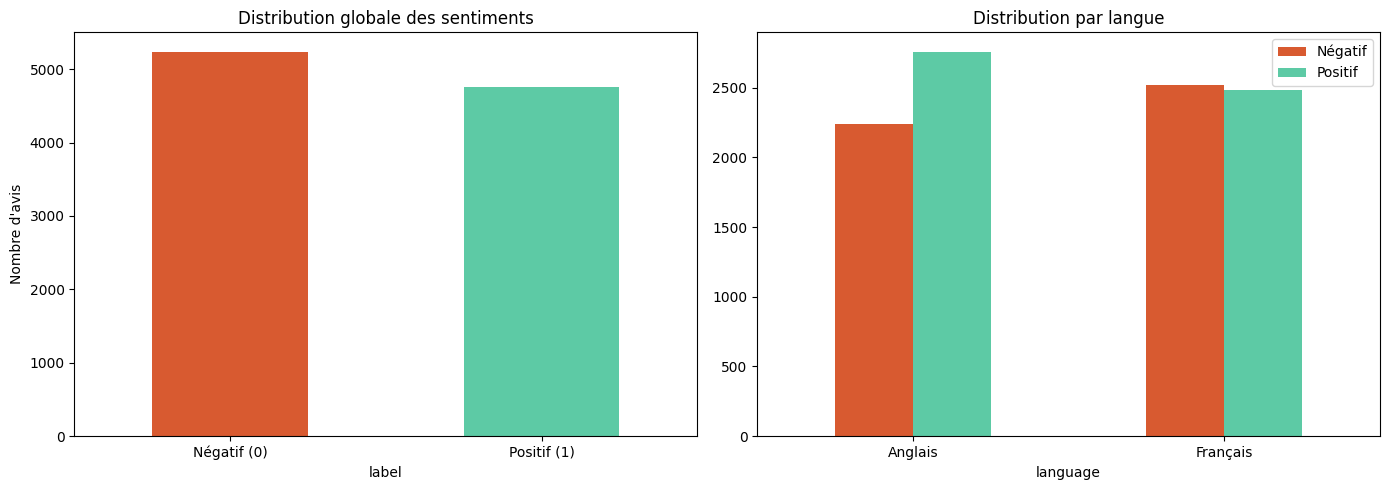

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#D85A30', '#5DCAA5']
)
axes[0].set_title("Distribution globale des sentiments")
axes[0].set_xticklabels(['Négatif (0)', 'Positif (1)'], rotation=0)
axes[0].set_ylabel("Nombre d'avis")

df.groupby(['language', 'label']).size().unstack().plot(
    kind='bar', ax=axes[1],
    color=['#D85A30', '#5DCAA5']
)
axes[1].set_title("Distribution par langue")
axes[1].set_xticklabels(['Anglais', 'Français'], rotation=0)
axes[1].legend(['Négatif', 'Positif'])

plt.tight_layout()
plt.show()

# Exemples

In [16]:
print("=== 3 avis POSITIFS français ===")
for _, row in df[(df['label']==1) & (df['language']=='french')].head(3).iterrows():
    print(f" {row['text'][:250]}\n")

print("=== 3 avis NÉGATIFS français ===")
for _, row in df[(df['label']==0) & (df['language']=='french')].head(3).iterrows():
    print(f" {row['text'][:250]}\n")

=== 3 avis POSITIFS français ===
 Premier film de la saga Kozure Okami, "Le Sabre de la vengeance" est un très bon film qui mêle drame et action, et qui, en 40 ans, n'a pas pris une ride.

 Tout commence comme une comédie légère avant un drame soudain qui fait basculer le film dans un...suspense incroyable mâtiné d'une étude psychologique très fine des mécanismes qui régissent un couple, en particulier, et un groupe social, en général. 

 un excellent film qui merite ses quatre étoiles. tellement bon que les ricains en font dejà une suite, qu'il s'empresseront de pourrir...

=== 3 avis NÉGATIFS français ===
 Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement douteux,"From Paris with love" est fait pour vous.Toutes les productions Besson,via sa filière EuropaCorp ont de quoi faire naître la

 Trash, re-trash et re-re-trash...! Une horreur sans nom. Imaginez-vous les 20 premières minutes de Orange Mécanique dilatées sur pl

# Longueur des avis

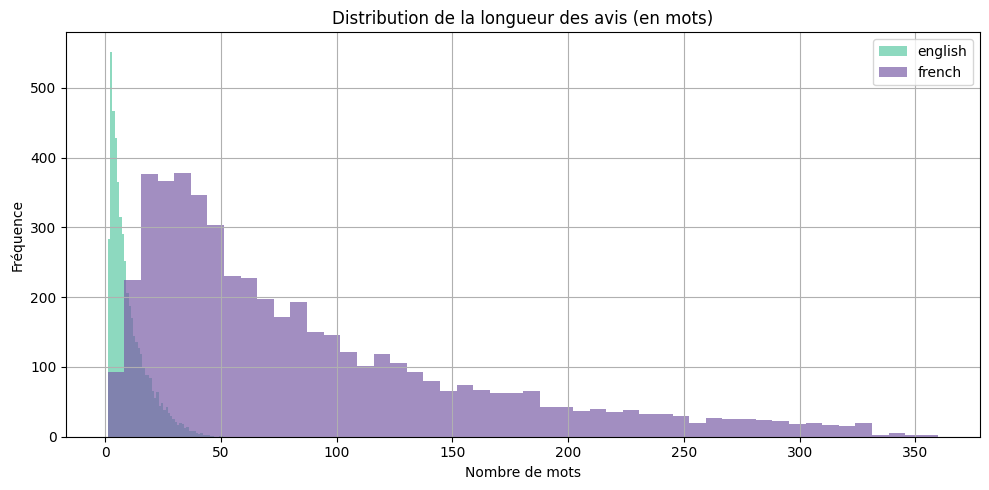


Longueur moyenne :
language
english     9.4
french     88.8
Name: review_length, dtype: float64

Longueur max :
language
english     51
french     360
Name: review_length, dtype: int64


In [17]:
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 5))
for lang, color in zip(['english', 'french'], ['#5DCAA5', '#7B5EA7']):
    df[df['language']==lang]['review_length'].hist(
        bins=50, alpha=0.7, ax=ax, color=color, label=lang
    )

ax.set_title("Distribution de la longueur des avis (en mots)")
ax.set_xlabel("Nombre de mots")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.show()

print("\nLongueur moyenne :")
print(df.groupby('language')['review_length'].mean().round(1))
print("\nLongueur max :")
print(df.groupby('language')['review_length'].max())